---
date: "2026-07-18"
date-modified: last-modified
format:
  html:
    toc: true
---

# The Probabilistic Method and Existence Proofs

One of the most profound and elegant strategies in modern combinatorics, discrete mathematics, and theoretical computer science is **The Probabilistic Method** (pioneered by [Paul Erdős](https://www.quantamagazine.org/after-80-years-mathematicians-give-famed-erdos-method-an-upgrade-20260626/)). Instead of attempting to explicitly construct a mathematical object with a complex desired property—which is often computationally or algebraically intractable—we introduce a probability distribution over a large universe of candidate objects and prove that a randomly drawn object possesses the property with strictly positive probability. This note formalizes the foundational First Moment Method and demonstrates its power through a classic combinatorial committee overlap problem.


## 1\. Core Foundations of the Probabilistic Method

The probabilistic method transforms deterministic existence statements into probabilistic calculations by leveraging simple properties of expectation and probability spaces.

::: {#thm-positive-probability-existence}
## Principle of Existence via Positive Probability
Let $\Omega$ be a finite or countable sample space of candidate mathematical objects, and let $P$ be a valid probability measure on $\Omega$. If $A \subseteq \Omega$ is the event that a randomly drawn object satisfies a desired property, and if:

$$
P(A) > 0
$$

then there exists **at least one** deterministic object $\omega \in \Omega$ that possesses property $A$ ($\omega \in A$).
:::

::: {.callout-note}
## Intuition: Why Positive Probability Guarantees Existence
If no object in the universe $\Omega$ possessed property $A$, the set $A$ would be strictly empty ($A = \emptyset$), forcing its probability to be zero ($P(A) = 0$). Therefore, the moment we establish that $P(A) > 0$ (even if $P(A) = 10^{-100}$), it is mathematically impossible for $A$ to be empty. At least one "good" configuration must exist!
:::

::: {#thm-first-moment-method}
## The First Moment Method (Expectation Argument)
Let $X: \Omega \to \mathbb{R}$ be a random variable representing a numerical **score** (such as the number of satisfied constraints, overlaps, or edges) assigned to each object in a finite sample space $\Omega$. Let $E(X)$ be the [expected value](expectation.ipynb) of this score across a random choice of object. Then:

1. **Existence above Mean:** There exists at least one object $\omega_1 \in \Omega$ whose score is at least the expected value:
   $$
   P(X \ge E(X)) > 0 \implies \exists \, \omega_1 \in \Omega \text{ such that } X(\omega_1) \ge E(X)
   $$
2. **Existence below Mean:** There exists at least one object $\omega_2 \in \Omega$ whose score is at most the expected value:
   $$
   P(X \le E(X)) > 0 \implies \exists \, \omega_2 \in \Omega \text{ such that } X(\omega_2) \le E(X)
   $$
3. **Integer Pigeonhole Refinement:** If the score $X$ strictly takes on **integer values** ($\mathbb{Z}$), then there must exist an object whose score is at least the ceiling of the mean, and one whose score is at most the floor of the mean:
   $$
   \exists \, \omega_1 \text{ such that } X(\omega_1) \ge \lceil E(X) \rceil \quad \text{and} \quad \exists \, \omega_2 \text{ such that } X(\omega_2) \le \lfloor E(X) \rfloor
   $$
:::

::: {.callout-tip collapse="true"}
## Proof of the First Moment Method
Suppose by way of contradiction that no object attains a score greater than or equal to $E(X)$. That is, assume $X(\omega) < E(X)$ for every single $\omega \in \Omega$.
Using the definition of expected value over a finite sample space $\Omega$:

$$
\begin{aligned}
E(X) &= \sum_{\omega \in \Omega} X(\omega) P(\{\omega\}) \\
&< \sum_{\omega \in \Omega} E(X) P(\{\omega\}) \quad \text{(since } X(\omega) < E(X) \text{ and } P(\{\omega\}) \ge 0 \text{ with at least one } P > 0\text{)} \\
&= E(X) \sum_{\omega \in \Omega} P(\{\omega\}) \\
&= E(X) \cdot 1 = E(X)
\end{aligned}
$$

This yields the strict inequality $E(X) < E(X)$, an absolute contradiction!
Therefore, the assumption is false, and there must exist at least one object with $X \ge E(X)$.
An identical proof by contradiction (assuming $X(\omega) > E(X)$ everywhere) establishes the lower bound $X \le E(X)$.

Finally, when $X$ takes only integer values, if an integer $X \ge E(X)$, it must be greater than or equal to the smallest integer above $E(X)$, which is precisely $\lceil E(X) \rceil$. $\blacksquare$
:::


## 2\. Problem Solving Strategy: The Indicator Decomposition Routine

To apply the First Moment Method to complex combinatorial structures, we follow a systematic four-step strategy:

1. **Randomize the Object Selection:** Define a uniform probability space over the set of candidate structures (e.g., choose a random graph, random permutation, or random pair of subsets).
2. **Decompose the Score into Indicators:** Express the global target quantity $X$ as the sum of simple binary [indicator random variables](indicator-rv.ipynb) targeting individual elements or constraints:
   $$
   X = \sum_{k=1}^m I_k, \quad \text{where } I_k = \begin{cases} 1 & \text{if constraint } k \text{ is satisfied} \\ 0 & \text{otherwise} \end{cases}
   $$
3. **Compute the Average via Linearity:** Use the fundamental [linearity of expectation](expectation.ipynb#properties-of-expectation) to compute $E(X)$ without needing the complex joint distribution of the indicators:
   $$
   E(X) = \sum_{k=1}^m E(I_k) = \sum_{k=1}^m P(I_k = 1)
   $$
4. **Invoke the First Moment Bound:** Compare $E(X)$ to the desired threshold. If $E(X) > c$, conclude immediately that there exists a deterministic structure attaining $X \ge \lceil E(X) \rceil \ge \lceil c \rceil$.


### 2.1\. Application: The Overlapping Committees Theorem

We now demonstrate this strategy on a classic combinatorial existence problem where explicit construction is extremely tedious.

::: {#thm-overlapping-committees}
## Theorem (Overlapping Committees Existence)
Suppose there are $100$ people who are organized into $15$ committees of $20$ people each. Every individual person belongs to exactly $3$ of the $15$ committees. Then there exist **at least two distinct committees** that share **at least $3$ members in common** (overlap $\ge 3$).
:::

::: {.callout-tip collapse="true"}
## Proof of Overlapping Committees via the Probabilistic Method
We apply our four-step probabilistic strategy:

**Step 1: Randomize the Object Selection**
Our candidate objects are the pairs of distinct committees. There are a total of:

$$
\binom{15}{2} = \frac{15 \times 14}{2} = 105 \text{ distinct pairs of committees}
$$

Let us select a pair of committees $\{C_i, C_j\}$ uniformly at random from these $105$ possible pairs, so each specific pair has selection probability $\frac{1}{105}$.

**Step 2: Decompose the Score into Indicators**
Let the random variable $X$ denote the **overlap**—the exact number of people belonging to both chosen committees $C_i$ and $C_j$.
To compute $X$, we decompose it across the population of $100$ people. For each person $k \in \{1, 2, \dots, 100\}$, define the indicator random variable:

$$
I_k = \begin{cases}
1 & \text{if person } k \text{ is a member of both } C_i \text{ and } C_j \\
0 & \text{otherwise}
\end{cases}
$$

The total overlap between committees $C_i$ and $C_j$ is the sum of these indicators across all people:

$$
X = \sum_{k=1}^{100} I_k
$$

**Step 3: Compute the Average via Linearity of Expectation**
By linearity of expectation, the expected overlap across a random pair of committees is:

$$
E(X) = E\left(\sum_{k=1}^{100} I_k\right) = \sum_{k=1}^{100} E(I_k) = \sum_{k=1}^{100} P(I_k = 1)
$$

We compute the exact probability $P(I_k = 1)$ for any individual person $k$.
By the problem statement, person $k$ is on exactly $3$ of the $15$ committees.
The indicator $I_k = 1$ if and only if both of our randomly selected committees $C_i$ and $C_j$ fall within the set of $3$ committees to which person $k$ belongs.
The number of favorable committee pairs made up exclusively of person $k$'s committees is $\binom{3}{2} = 3$.
Since all $\binom{15}{2} = 105$ pairs are equally likely:

$$
P(I_k = 1) = \frac{\binom{3}{2}}{\binom{15}{2}} = \frac{3}{105} = \frac{1}{35}
$$

Because this probability is identical for every one of the $100$ people, we sum:

$$
E(X) = \sum_{k=1}^{100} \frac{1}{35} = 100 \times \frac{1}{35} = \frac{100}{35} = \frac{20}{7} \approx 2.8571
$$

**Step 4: Invoke the First Moment Bound**
By the First Moment Method, because the average overlap across all $105$ pairs of committees is exactly $E(X) = \frac{20}{7} \approx 2.857$, there must exist at least one specific pair of committees $\{C_i^*, C_j^*\}$ whose overlap is at least the average:

$$
X(C_i^*, C_j^*) \ge E(X) = \frac{20}{7}
$$

Furthermore, because the number of overlapping people $X$ must be a strict integer, if an integer is greater than or equal to $2.8571$, it must be at least $\lceil 2.8571 \rceil = 3$:

$$
X(C_i^*, C_j^*) \ge \left\lceil \frac{20}{7} \right\rceil = 3
$$

Thus, there exist at least two distinct committees with an overlap of $3$ or more members! $\blacksquare$
:::

::: {.callout-note}
## Intuition: The Power of Linearity over Dependency
Notice that the membership indicators $I_1, I_2, \dots, I_{100}$ are **not independent**! For example, if committee sizes are capped at $20$, knowing that many people overlap on $\{C_i, C_j\}$ reduces the remaining space on those committees for other people. However, **linearity of expectation holds universally for dependent variables**! By avoiding the intractable joint distribution of overlaps and solely summing marginal expectations, we bypassed complex combinatorial enumeration to prove existence in three lines of arithmetic.
:::

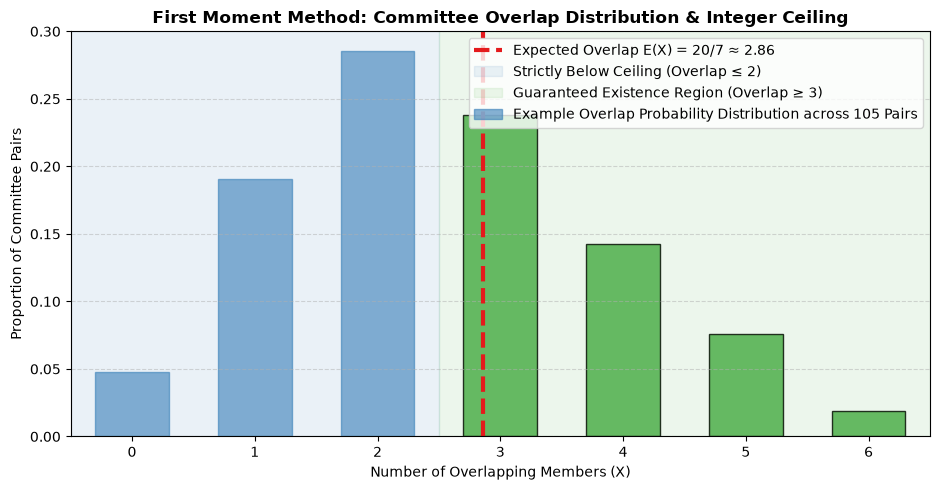

In [1]:
#| label: fig-committee-overlap-bounds
#| fig-cap: "Visualizing the First Moment Method on the Overlapping Committees Problem. Because the average overlap across all 105 committee pairs is strictly E(X) = 20/7 ≈ 2.86 (red dashed line), and because overlap counts must be discrete integers, it is mathematically impossible for all pairs to have overlap ≤ 2 (shaded forbidden region). At least one pair must cross into the integer ceiling ≥ 3."

import numpy as np
import matplotlib.pyplot as plt

# We illustrate the pigeonhole constraint: if all 105 pairs had overlap <= 2,
# the maximum possible mean overlap would be strictly capped at 2.0.
# Since E[X] = 2.857, probability mass MUST exist at integer scores >= 3.

possible_overlaps = np.array([0, 1, 2, 3, 4, 5, 6])
# Example distribution of overlaps across the 105 pairs that achieves mean 20/7
# showing exact integer support requiring tail mass >= 3
example_counts = np.array([5, 20, 30, 25, 15, 8, 2])
example_probs = example_counts / np.sum(example_counts)
mean_val = np.sum(possible_overlaps * example_probs) # ≈ 2.857

plt.figure(figsize=(9.5, 5))
bars = plt.bar(possible_overlaps, example_probs, color='#4daf4a', width=0.6, edgecolor='black', alpha=0.85, label='Example Overlap Probability Distribution across 105 Pairs')

# Highlight integer regions
for i in range(3):
    bars[i].set_color('#377eb8')
    bars[i].set_alpha(0.6)

plt.axvline(x=20/7, color='#e41a1c', linestyle='--', linewidth=3, label='Expected Overlap E(X) = 20/7 ≈ 2.86')
plt.axvspan(-0.5, 2.5, color='#377eb8', alpha=0.1, label='Strictly Below Ceiling (Overlap ≤ 2)')
plt.axvspan(2.5, 6.5, color='#4daf4a', alpha=0.1, label='Guaranteed Existence Region (Overlap ≥ 3)')

plt.title('First Moment Method: Committee Overlap Distribution & Integer Ceiling', fontsize=12, fontweight='bold')
plt.xlabel('Number of Overlapping Members (X)')
plt.ylabel('Proportion of Committee Pairs')
plt.xticks(possible_overlaps)
plt.xlim(-0.5, 6.5)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

> **References & Acknowledgments:**
> Notes adapted from Stat 110: Probability (Lecture 22: Transformations and Convolutions) by Joe Blitzstein ([YouTube Reference](https://www.youtube.com/watch?v=yXwPUAIvFyg&list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo&index=22)).